# Notebook para entrenar modelos

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from project.loader import Loader
from project.models_definitions import Encoder, Decoder, CVAE
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping

## parametros
dataset="mnist"
data = Loader.data(dataset=dataset)

x_train = data["x_train"]
y_train = data["y_train"]

x_test = data["x_test"]
y_test =data["y_test"]

x_val = data["x_val"]
y_val = data["y_val"]

original_dim = 28*28
beta = 1.0

train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(128)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)

intermediate_dim = [128,128,256,256,512,512,784]
latent_dim =      [2,64,64,128,128,256,784]


for i,l in zip(intermediate_dim,latent_dim):

    en = Encoder(
        intermediate_dim=i,
        latent_dim=l,
    )
    de = Decoder(
        intermediate_dim=i,
        latent_dim=l,
    )
    cvae_model = CVAE(
        encoder=en,
        decoder=de,
        original_dim=original_dim,
        beta=beta,
        name=f"cvae_int_{i}_lat_{l}_gamma_2",
    )


    optimizer = tf.keras.optimizers.Adam()
    cvae_model.compile(optimizer=optimizer)


    cvae_model.total_loss_tracker.reset_state()
    cvae_model.reconstruction_loss_tracker.reset_state()
    cvae_model.kl_loss_tracker.reset_state()

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = cvae_model.fit(
        train_dataset,
        epochs=10,
        batch_size=128,
        validation_data=val_dataset,
        callbacks=[early_stopping],
        verbose=1
    )

    #en.save(f"en_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")
    #de.save(f"de_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")


    loss_val = round(history.history["loss"][-1], 3)
    recon_val = round(history.history["reconstruction_loss"][-1], 3)
    kl_val = round(history.history["kl_loss"][-1], 3)
    
    plt.plot(history.history["loss"], label=f"total_loss ({loss_val})")
    plt.plot(history.history["reconstruction_loss"], label=f"reconstruction_loss ({recon_val})")
    plt.plot(history.history["kl_loss"], label=f"kl_loss ({kl_val})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.title("Training vs Epochs")
    plt.legend()
    #plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
    plt.show()
    loss_val = round(history.history["loss"][-1], 3)
    val_loss_val = round(history.history["val_loss"][-1], 3)
    
    plt.plot(history.history["loss"], label=f"total_loss ({loss_val})")
    plt.plot(history.history["val_loss"], label=f"val_loss ({val_loss_val})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.title("Training vs Validation Loss")
    plt.legend()
    #plt.savefig(f"training_loss_vs_val_loss_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
    plt.show()


2026-04-11 15:23:45.275557: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-11 15:23:45.275924: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-11 15:23:45.278069: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-11 15:23:45.283925: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775931825.294194  149381 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775931825.29

Usando mnist como dataset


2026-04-11 15:23:48.417854: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
160/430 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 7.1221 - loss: 105.5833 - reconstruction_loss: 98.4612 

KeyboardInterrupt: 

## Test de modelo entrenado. 

Usando mnist como dataset


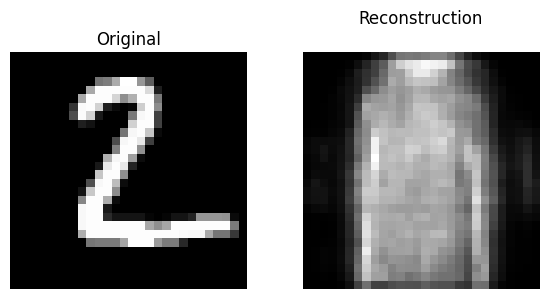

In [2]:
import numpy as np
dataset="mnist"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]

y_train = data["y_train"]
y_val = data["y_val"]
y_test =data["x_test"]



x_test = data["x_test"]
y_test = data["y_test"]


x = x_test[1 :  2]  # (1, 28, 28)
y = y_test[1 :  2]  # (1, 10)

# Codificar
z_mean, _, z = cvae_model.encoder.predict([x, y], verbose=0)

# Decodificar
x_recon = cvae_model.decoder.predict([z, y], verbose=0)



x_pic = tf.reshape(x, (28, 28))
x_recon = tf.reshape(x_recon, (28, 28))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(x_pic, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(x_recon, cmap="gray")
axes[1].set_title(f"Reconstruction\n{cvae_model.name}")
axes[1].axis("off")

plt.tight_layout()
plt.show()



## Modelo con más capas ocultas

In [6]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

import project.loader.load as load
from project.models_definitions import encoder
from project.models_definitions import decoder
from project.models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping


from keras.layers import Input, Concatenate, Dense
from keras.models import Model
from project.custom_layers.sampling import Sampling



def build_enconder(img_dim=(28,28),condition_dim=(10,),intermediate_dim_1=128,intermediate_dim_2=128,latent_dim=2):
    flat_dim = img_dim[0]*img_dim[1]
    
    img_input = Input(shape=(flat_dim,), name="img_input_encoder")
    cond_encoder = Input(shape=(condition_dim), name="encoder_condition")

    imputs_cocanteados = Concatenate()([img_input, cond_encoder])
    
    x = Dense(intermediate_dim_1, activation="relu")(imputs_cocanteados)
    x = Dense(intermediate_dim_2, activation="relu")(x)
    z_mean = Dense(latent_dim, name="z_mean")(x)
    z_log_var = Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()((z_mean, z_log_var))
    encoder = Model(inputs=[img_input, cond_encoder], outputs=[z_mean, z_log_var, z], name="encoder")
    return encoder

In [7]:
from keras.layers import Input, Dense, Concatenate
from keras.models import Model


def build_decoder(latent_dim=2, cond_dim=(10,), intermediate_dim_1=128,intermediate_dim_2=128, original_shape=(28, 28)):
    original_dim = original_shape[0] * original_shape[1]

    z_inputs = Input(shape=(latent_dim,), name="z_sampling")
    cond_decoder = Input(shape=cond_dim, name="decoder_condition")
    
    latent_inputs = Concatenate()([z_inputs, cond_decoder])

    x = Dense(intermediate_dim_1, activation="relu")(latent_inputs)
    x = Dense(intermediate_dim_2, activation="relu")(x)
    decoder_outputs = Dense(original_dim, activation="sigmoid")(x)

    decoder = Model(inputs=[z_inputs, cond_decoder], outputs=decoder_outputs, name="decoder")
    return decoder


Usando mnist como dataset
Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 0.8236 - loss: 49.4040 - reconstruction_loss: 48.5824 - val_kl_loss: 1.3421 - val_loss: 40.4451 - val_reconstruction_loss: 39.1786
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 2.4081 - loss: 38.8936 - reconstruction_loss: 36.4850 - val_kl_loss: 3.1200 - val_loss: 35.9877 - val_reconstruction_loss: 32.8281
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.4664 - loss: 35.8371 - reconstruction_loss: 32.3700 - val_kl_loss: 3.7411 - val_loss: 33.7042 - val_reconstruction_loss: 29.9880
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.9500 - loss: 33.3679 - reconstruction_loss: 29.4176 - val_kl_loss: 3.9172 - val_loss: 31.2399 - val_reconstruction_loss: 27.3088
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 4.3358 - loss: 31.3955 - reconstruction_loss: 27.0589 - val_kl_loss: 4.3497 - val_loss: 29.8892 - val_reconstruction_loss: 25

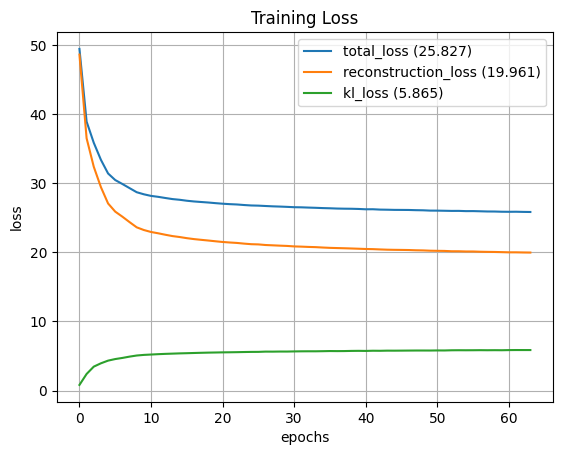

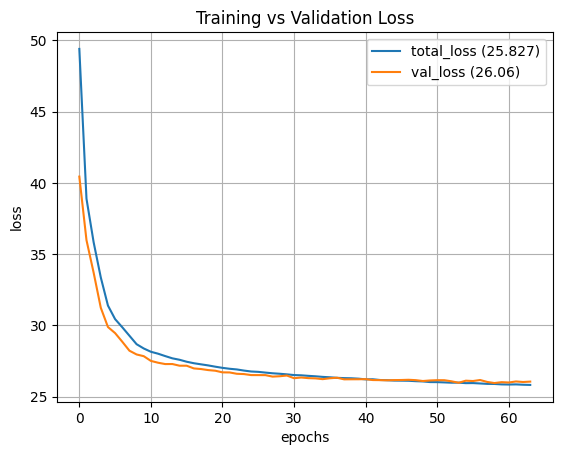

In [9]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

import project.loader.load as load
from project.models_definitions import encoder
from project.models_definitions import decoder
from project.models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping

## parametros
dataset="mnist"
data = load.data(dataset=dataset)

x_train = data["x_train"]
y_train = data["y_train"]

x_test = data["x_test"]
y_test =data["x_test"]

x_val = data["x_val"]
y_val = data["y_val"]

original_dim = 28*28
beta = 1.0

train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(128)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)


intermediate_dim_1 = [512]
intermediate_dim_2 = [256]
latent_dim =      [128]



for i in range(len(intermediate_dim)):


    en =build_enconder(
        intermediate_dim_1=intermediate_dim_1[i],
        intermediate_dim_2=intermediate_dim_2[i],
        
        latent_dim=latent_dim[i],
    )
    de = build_decoder(
        intermediate_dim_1=intermediate_dim_1[i],
        intermediate_dim_2=intermediate_dim_2[i],
        
        latent_dim=latent_dim[i],
    )
    cvae_model = CVAE(
        encoder=en,
        decoder=de,
        original_dim=original_dim,
        beta=beta,
    )


    optimizer = tf.keras.optimizers.Adam()
    cvae_model.compile(optimizer=optimizer)


    cvae_model.total_loss_tracker.reset_state()
    cvae_model.reconstruction_loss_tracker.reset_state()
    cvae_model.kl_loss_tracker.reset_state()

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = cvae_model.fit(
        train_dataset,
        epochs=1000,
        batch_size=128,
        validation_data=val_dataset,
        callbacks=[early_stopping],
        verbose=1
    )

    en.save(f"en_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}_three_layers_512_256_128.keras")
    de.save(f"de_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}_three_layers_512_256_128.keras")


    plt.plot(history.history["loss"], label=f"total_loss ({round(history.history["loss"][-1],3)})")
    plt.plot(history.history["reconstruction_loss"], label=f"reconstruction_loss ({round(history.history["reconstruction_loss"][-1],3)})")
    plt.plot(history.history["kl_loss"], label=f"kl_loss ({round(history.history["kl_loss"][-1],3)})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.legend()
    plt.title("Training Loss")
    plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}_three_layers_512_256_128")
    plt.show()

    plt.plot(history.history["loss"], label=f"total_loss ({round(history.history["loss"][-1],3)})")
    plt.plot(history.history["val_loss"], label=f"val_loss ({round(history.history["val_loss"][-1],3)})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.savefig(f"training_loss_vs_val_loss_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}_three_layers_512_256_128")
    plt.show()
